In [ ]:
# Imports
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import math
from io import BytesIO


In [16]:
def mol_image(smiles_or_mol, size=(240,240), atom_labels=None):
    """Return a PIL.Image of the molecule for the given SMILES or RDKit Mol.
    If `atom_labels` is provided (dict idx->label) they will be overlaid on the image.
    Otherwise any atom with the 'atomLabel' property will be used.
    """
    if isinstance(smiles_or_mol, str):
        mol = Chem.MolFromSmiles(smiles_or_mol)
    elif isinstance(smiles_or_mol, Chem.Mol):
        mol = Chem.Mol(smiles_or_mol)
    else:
        raise ValueError("Unsupported input to mol_image")
    if mol is None:
        raise ValueError("Invalid SMILES or molecule")
    try:
        rdDepictor.Compute2DCoords(mol)
    except Exception:
        pass

    if atom_labels is None:
        atom_labels = {}
        for a in mol.GetAtoms():
            if a.HasProp('atomLabel'):
                atom_labels[a.GetIdx()] = a.GetProp('atomLabel')

    # Render base image using RDKit's MolToImage
    pil = Draw.MolToImage(mol, size=size).convert('RGBA')

    # If there are atom labels, overlay them using the 2D conformer coords
    if atom_labels:
        conf = mol.GetConformer()
        xs = [conf.GetAtomPosition(i).x for i in range(mol.GetNumAtoms())]
        ys = [conf.GetAtomPosition(i).y for i in range(mol.GetNumAtoms())]
        minx, maxx = min(xs), max(xs)
        miny, maxy = min(ys), max(ys)
        dx = maxx - minx if (maxx - minx) != 0 else 1.0
        dy = maxy - miny if (maxy - miny) != 0 else 1.0
        w, h = pil.size
        pad = max(4, int(0.04 * max(w, h)))
        draw = ImageDraw.Draw(pil)
        try:
            font = ImageFont.truetype('arial.ttf', 14)
        except Exception:
            font = ImageFont.load_default()

        for idx, label in atom_labels.items():
            pos = conf.GetAtomPosition(int(idx))
            # map molecule coords -> image pixels (simple linear mapping)
            xp = pad + (pos.x - minx) / dx * (w - 2 * pad)
            yp = pad + (pos.y - miny) / dy * (h - 2 * pad)
            # RDKit y-axis is upwards; image y is downwards
            yp = h - yp
            # measure text size safely
            try:
                bbox = draw.textbbox((0, 0), label, font=font)
                tw = bbox[2] - bbox[0]
                th = bbox[3] - bbox[1]
            except Exception:
                try:
                    tw, th = font.getsize(label)
                except Exception:
                    tw, th = (len(label) * 6, 12)
            # draw a semi-opaque background to keep label legible
            rect = (xp - tw / 2 - 3, yp - th / 2 - 1, xp + tw / 2 + 3, yp + th / 2 + 1)
            draw.rectangle(rect, fill=(255, 255, 255, 220))
            draw.text((xp - tw / 2, yp - th / 2), label, fill=(0, 0, 0), font=font)

    return pil


def concat_images_h(images, bg=(255,255,255,0), valign='center'):
    widths = [im.width for im in images]
    heights = [im.height for im in images]
    total_w = sum(widths)
    max_h = max(heights)
    canvas = Image.new('RGBA', (total_w, max_h), bg)
    x = 0
    for im in images:
        if valign == 'center':
            y = (max_h - im.height)//2
        elif valign == 'top':
            y = 0
        else:
            y = max_h - im.height
        canvas.paste(im, (x, y), im)
        x += im.width
    return canvas


def draw_arrow(size=(120,240), color=(0,0,0,255), thickness=10):
    w,h = size
    img = Image.new('RGBA', (w,h), (255,255,255,0))
    draw = ImageDraw.Draw(img)
    y = h//2
    draw.line([(10,y),(w-25,y)], fill=color, width=thickness)
    head = [(w-25,y-18),(w-6,y),(w-25,y+18)]
    draw.polygon(head, fill=color)
    return img


def draw_reaction(reactant_smiles, reagent_smiles, product_smiles, mol_size=(240,240), spacing=20, reagent_text_size=14):
    """Compose a reaction scheme image and return a PIL.Image.
    Inputs may be lists of SMILES, single SMILES strings, or SMILES separated by '.' or '+'.
    """
    def to_list(x):
        if x is None or x == '':
            return []
        if isinstance(x, list):
            return x
        # accept '.' or '+' as separators (common for multiple fragments)
        if '+' in x or '.' in x:
            parts = [p.strip() for p in x.replace('.', '+').split('+') if p.strip()]
            return parts
        return [x.strip()]

    reactants = to_list(reactant_smiles)
    reagents = to_list(reagent_smiles)
    products = to_list(product_smiles)

    # Render molecule images (use a placeholder for empty lists)
    r_imgs = [mol_image(s, size=mol_size) for s in reactants] if reactants else [Image.new('RGBA', mol_size, (255,255,255,0))]
    p_imgs = [mol_image(s, size=mol_size) for s in products] if products else [Image.new('RGBA', mol_size, (255,255,255,0))]

    left = concat_images_h(r_imgs)
    right = concat_images_h(p_imgs)
    arrow = draw_arrow(size=(120, max(left.height, right.height)), color=(0,0,0,255), thickness=10)

    # Compose full canvas
    total_w = left.width + spacing + arrow.width + spacing + right.width
    text_area_h = 60
    total_h = max(left.height, arrow.height, right.height) + text_area_h
    canvas = Image.new('RGBA', (total_w, total_h), (255,255,255,255))
    x = 0
    canvas.paste(left, (x,0), left)
    x += left.width + spacing
    canvas.paste(arrow, (x,0), arrow)
    x += arrow.width + spacing
    canvas.paste(right, (x,0), right)

    # Draw reagent text centered underneath
    draw = ImageDraw.Draw(canvas)
    try:
        font = ImageFont.truetype('arial.ttf', reagent_text_size)
    except Exception:
        font = ImageFont.load_default()

    reagent_text = ''
    if reagents:
        reagent_text = 'Reagents: ' + ', '.join(reagents)
    # Compute text size: prefer textbbox, fall back to font.getsize for compatibility
    try:
        bbox = draw.textbbox((0, 0), reagent_text, font=font)
        w_text = bbox[2] - bbox[0]
        h_text = bbox[3] - bbox[1]
    except Exception:
        try:
            w_text, h_text = font.getsize(reagent_text)
        except Exception:
            # Fallback conservative estimate
            w_text, h_text = (len(reagent_text) * (reagent_text and 6 or 0), 12)
    draw.text(((total_w - w_text)//2, total_h - text_area_h + (text_area_h - h_text)//2), reagent_text, fill=(0,0,0), font=font)

    return canvas.convert('RGB')


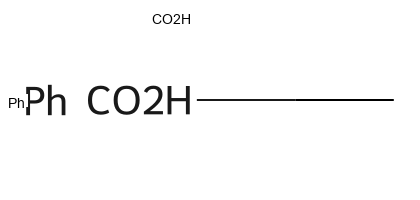

In [17]:
def abbreviate_mol_for_drawing(mol_or_smiles, abbrev_map):
    """Replace matching substructures with a single wildcard atom carrying an 'atomLabel'.
    Returns a new RDKit Mol ready for drawing with `mol_image` which will pick up labels.
    abbrev_map: dict of SMARTS -> abbreviation string
    """
    if isinstance(mol_or_smiles, str):
        mol = Chem.MolFromSmiles(mol_or_smiles)
    else:
        mol = Chem.Mol(mol_or_smiles)
    if mol is None:
        raise ValueError("Invalid molecule")

    for smarts, label in abbrev_map.items():
        patt = Chem.MolFromSmarts(smarts)
        if patt is None:
            continue
        repl = Chem.MolFromSmiles('[*]')
        repl.GetAtomWithIdx(0).SetProp('atomLabel', label)
        res = Chem.ReplaceSubstructs(mol, patt, repl, replaceAll=True)
        if res:
            mol = res[0]

    try:
        rdDepictor.Compute2DCoords(mol)
    except Exception:
        pass
    return mol

# Example: replace phenyl and carboxylate fragments with abbreviations and draw
abbr = {'c1ccccc1': 'Ph', 'C(=O)O': 'CO2H'}
orig_smiles = 'c1ccc(cc1)CC(=O)O'
mol_abbr = abbreviate_mol_for_drawing(orig_smiles, abbr)
img_abbr = mol_image(mol_abbr, size=(420,200))
display(img_abbr)


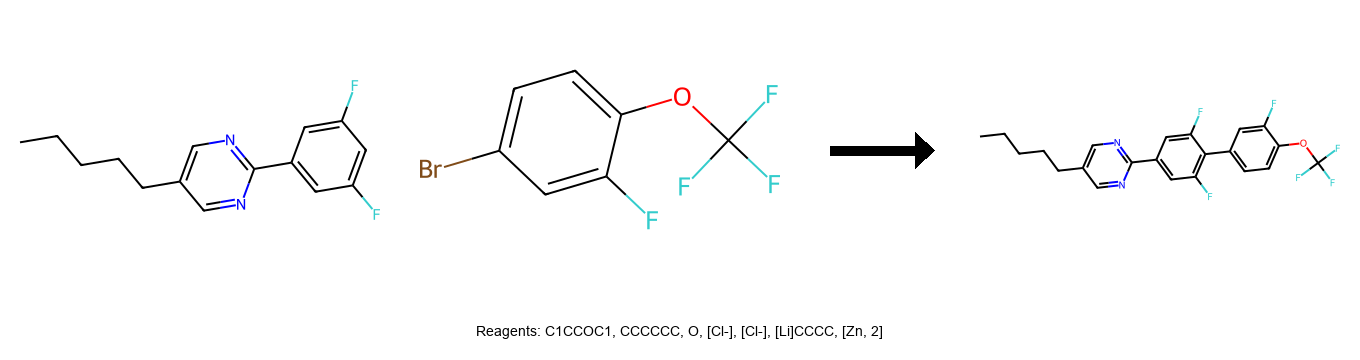

In [11]:
# Example usage: define SMILES and render
reactants = 'CCCCCc1cnc(-c2cc(F)cc(F)c2)nc1.Fc1cc(Br)ccc1OC(F)(F)F' 
reagents = 'C1CCOC1.CCCCCC.O.[Cl-].[Cl-].[Li]CCCC.[Zn+2]'
products = 'CCCCCc1cnc(-c2cc(F)c(-c3ccc(OC(F)(F)F)c(F)c3)c(F)c2)nc1'
img = draw_reaction(reactants, reagents, products, mol_size=(400,300))
display(img)